In [1]:
from getdist import plots, loadMCSamples, MCSamples
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
import uncertainties
import scipy

g = plots.get_subplot_plotter(width_inch=10)
g.settings.axes_fontsize=15
g.settings.axes_labelsize=15
g.settings.alpha_filled_add = 0.6
g.settings.legend_fontsize = 15
%matplotlib inline

colours = ['salmon','deepskyblue', 'brown', 'black']

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir='/n17data/sguerrini/mcmc_xi_sys/'
versions = ['SP_v1.4.1', 'SP_v1.4.1_noleakage']
roots = ['no_scale_cut']


## Retrieve the chains

In [2]:
#CREATE PARAMNAME FILE
for version in versions:
    for root in roots:
        with open(root_dir + '{}/samples_{}_1.txt'.format(version+'/'+root ,version), "r") as file:
            params = file.readline()[1:].split('\t')[:-2]
            file.close()

        with open(root_dir + '{}/getdist_{}.paramnames'.format(version+'/'+root,version), "w") as file:
            for i in range(len(params)):
                file.write(params[i].split('--')[1] + '\n')
            file.close()
        print(params)

['cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8_input', 'intrinsic_alignment_parameters--a', 'psf_leakage_parameters--alpha', 'psf_leakage_parameters--beta', 'COSMOLOGICAL_PARAMETERS--OMEGA_LAMBDA', 'COSMOLOGICAL_PARAMETERS--S_8']
['cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8_input', 'intrinsic_alignment_parameters--a', 'psf_leakage_parameters--alpha', 'psf_leakage_parameters--beta', 'COSMOLOGICAL_PARAMETERS--OMEGA_LAMBDA', 'COSMOLOGICAL_PARAMETERS--S_8']


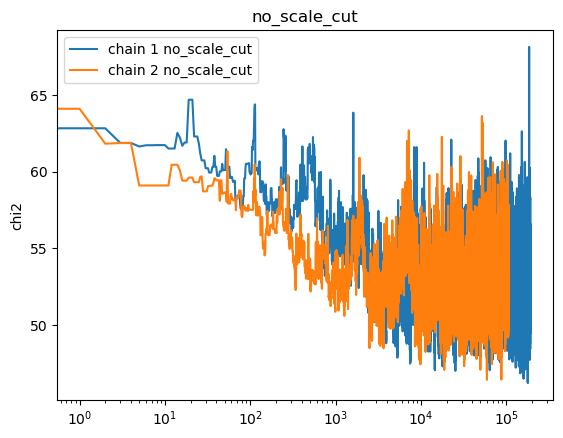

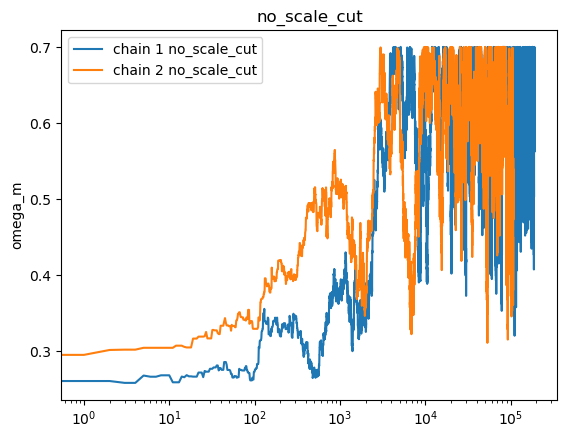

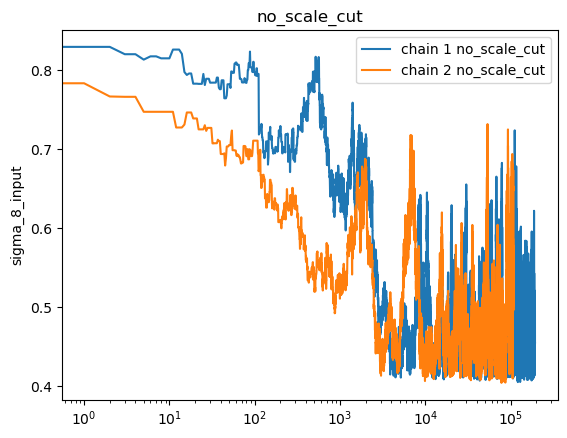

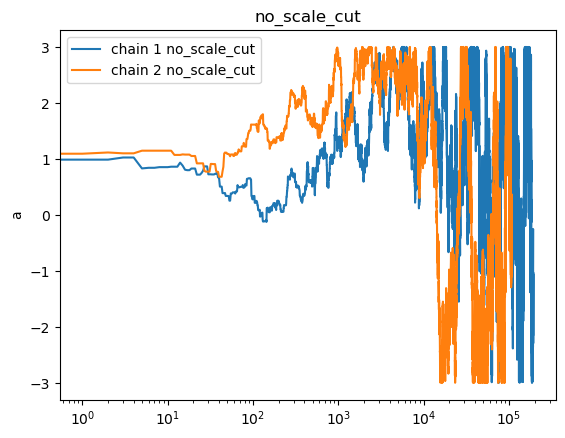

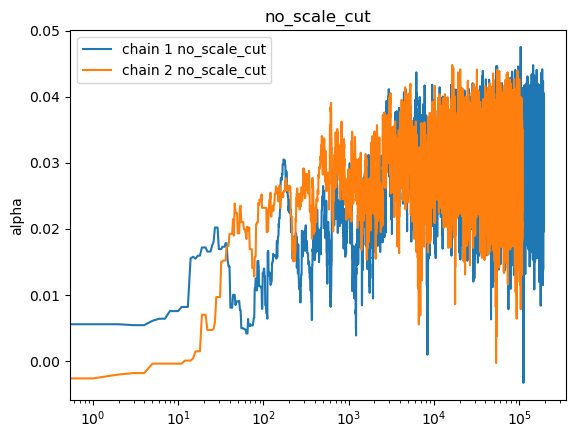

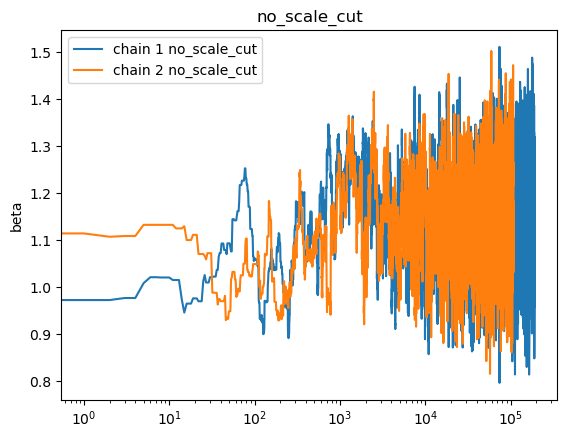

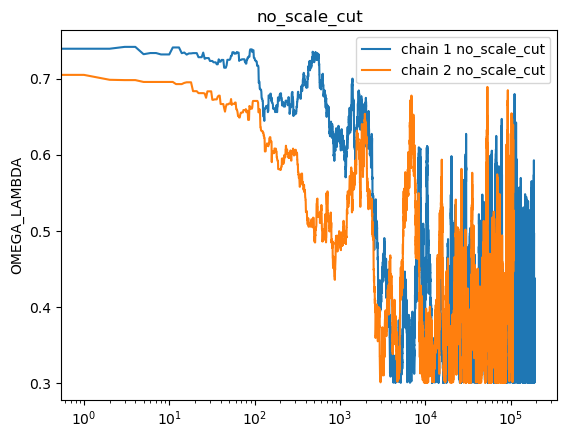

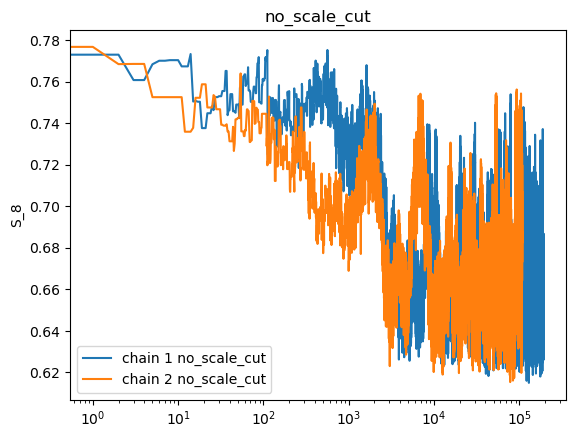

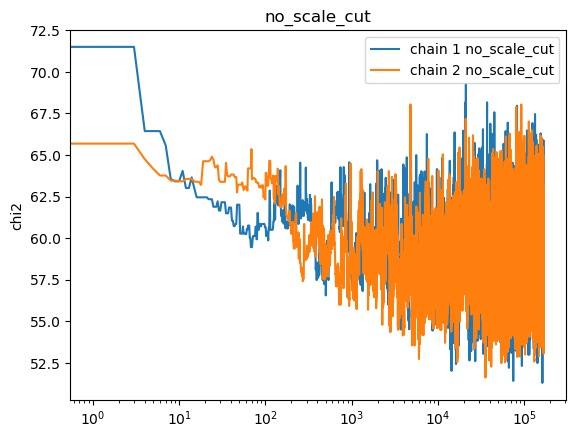

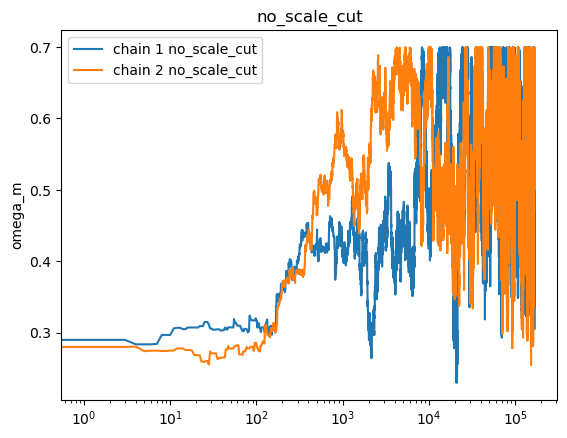

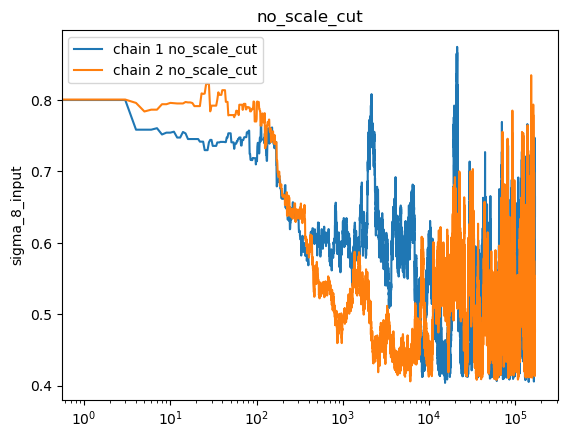

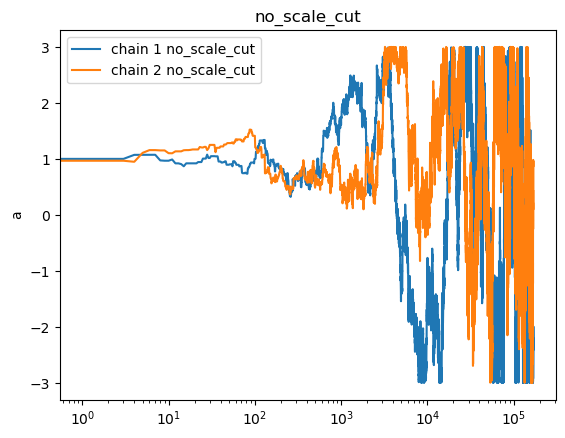

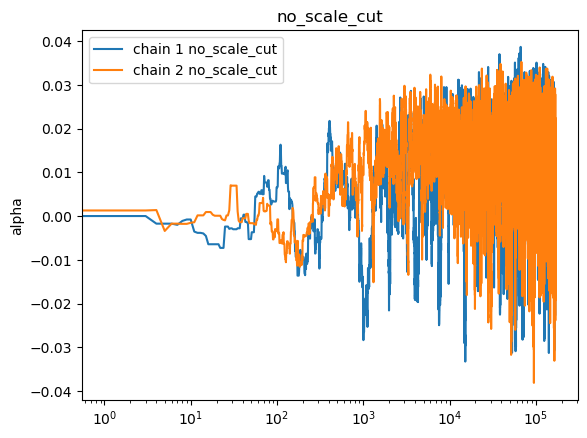

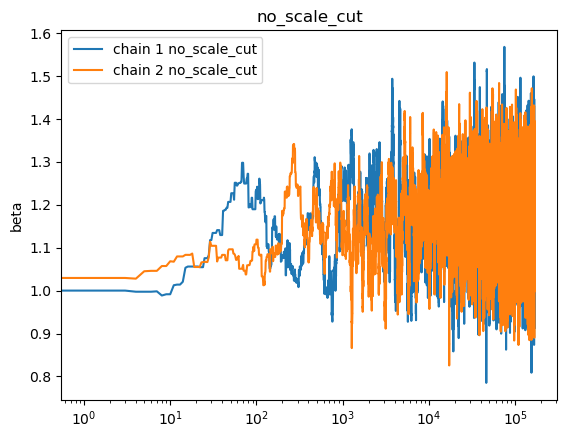

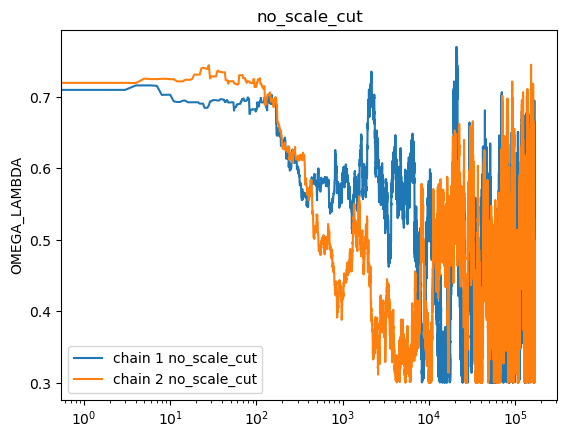

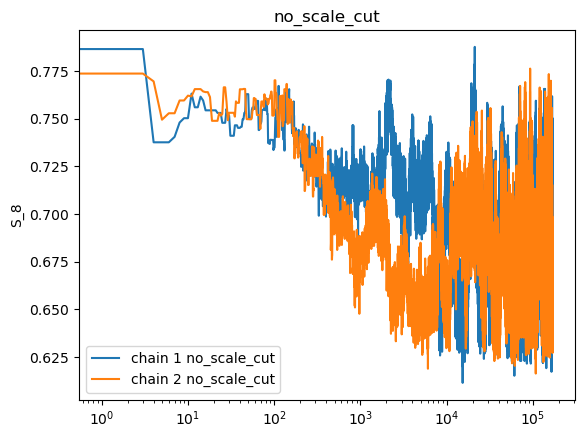

In [3]:
#PLOT CHAIN TRENDS

Nchains = 2
for version in versions:
    for root in roots:
        params = np.genfromtxt(root_dir + '{}/getdist_{}.paramnames'.format(version+'/'+root,version),dtype='str')
        params = np.insert(params,0, 'chi2')

        for idx,par in enumerate(params):
            for i in range(1,Nchains+1):
                
                chain = np.loadtxt(root_dir + '{}/samples_{}_{}.txt'.format(version+'/'+root,version,i))

                np.savetxt(root_dir + '{}/getdist_{}_{}.txt'.format(version+'/'+root,version,i),  
                    np.column_stack((np.ones_like(chain[:, -1]) ,-(chain[:, -1]-chain[:, -2]), chain[:, 0:-2])))
            
                trend = np.loadtxt(root_dir + '{}/getdist_{}_{}.txt'.format(version+'/'+root,version,i),usecols=idx+1)
                plt.plot(trend, label='chain {} {}'.format(i,root))
                plt.xscale('log')
                plt.legend()
                plt.ylabel('%s'%par)
                plt.title('%s'%root)
            plt.show()

In [4]:
#READ CHAIN

chains=[]

for version in versions:
    for root in roots:

        chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(version +'/' +root,version),
                                    settings={'ignore_rows':0.3})
        
        cov = chain.getCov(pars=np.arange(0,len(params)-3))
        np.savetxt(root_dir + '{}/getdist_cov.txt'.format(version+'/'+root),cov)

        print('R-1 of %s = %s' %(root, chain.getGelmanRubin(nparam=3)))
        chains.append(chain)

/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_1.txt


/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_2.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_3.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_4.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_5.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_6.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1/no_scale_cut/getdist_SP_v1.4.1_7.txt
Removed 0.3 as burn in
R-1 of no_scale_cut = 0.09281348884993046
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1_noleakage/no_scale_cut/getdist_SP_v1.4.1_noleakage_1.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1_noleakage/no_scale_cut/getdist_SP_v1.4.1_noleakage_2.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1_noleakage/no_scale_cut/getdist_SP_v1.4.1_noleakage_3.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1_noleakage/no_scale_cut/getdist_SP_v1.4.1_noleakage_4.txt
/n17data/sguerrini/mcmc_xi_sys/SP_v1.4.1_noleakage/no_scale_cut/getdist_SP_

In [5]:
for version in versions:
    samples = np.load(f'/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/samples_{version}.npy')
    chain = MCSamples(samples=samples[:, :2], names=['alpha', 'beta'], labels=['alpha', 'beta'])
    chains.append(chain)

Removed no burn in
Removed no burn in


## Plot the chain

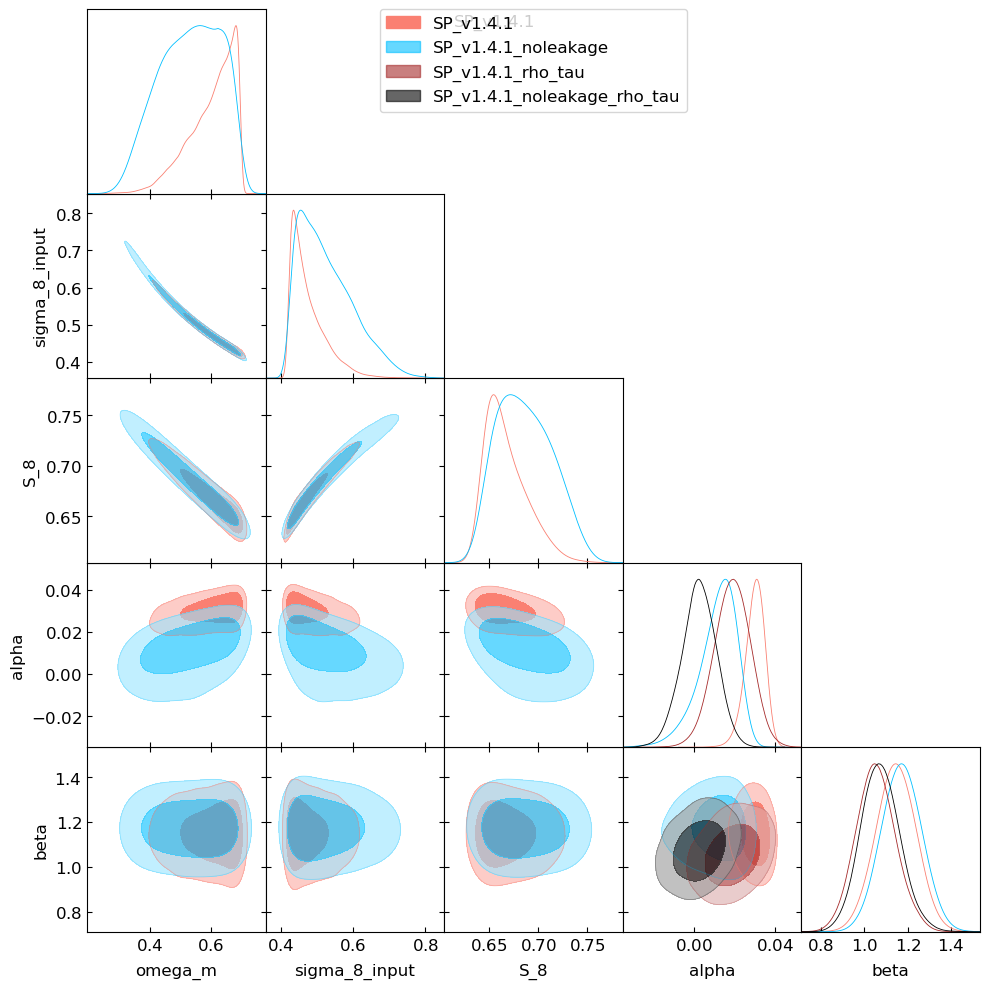

In [6]:
g.triangle_plot(chains,['omega_m','sigma_8_input','S_8', 'alpha', 'beta'],
                legend_labels=['SP_v1.4.1', 'SP_v1.4.1_noleakage', 'SP_v1.4.1_rho_tau', 'SP_v1.4.1_noleakage_rho_tau'],
                colors=colours,
                line_args=[{'color':colours[i]} for i in range(len(chains))],
                filled=True)
plt.suptitle(versions[0])
g.export('corner_plot_leakage_'+versions[0]+'.pdf')

## Looking at $\xi_{\rm sys}$ predictions

In [7]:
from astropy.io import fits

version = 'SP_v1.4.1'

xi_plus = fits.getdata(f'/home/guerrini/sp_validation/notebooks/cosmo_val/output/xi_plus_{version}.fits')
xi_minus = fits.getdata(f'/home/guerrini/sp_validation/notebooks/cosmo_val/output/xi_minus_{version}.fits')
cov_mat = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{version}/cosmosis_{version}.fits')['COVMAT'].data

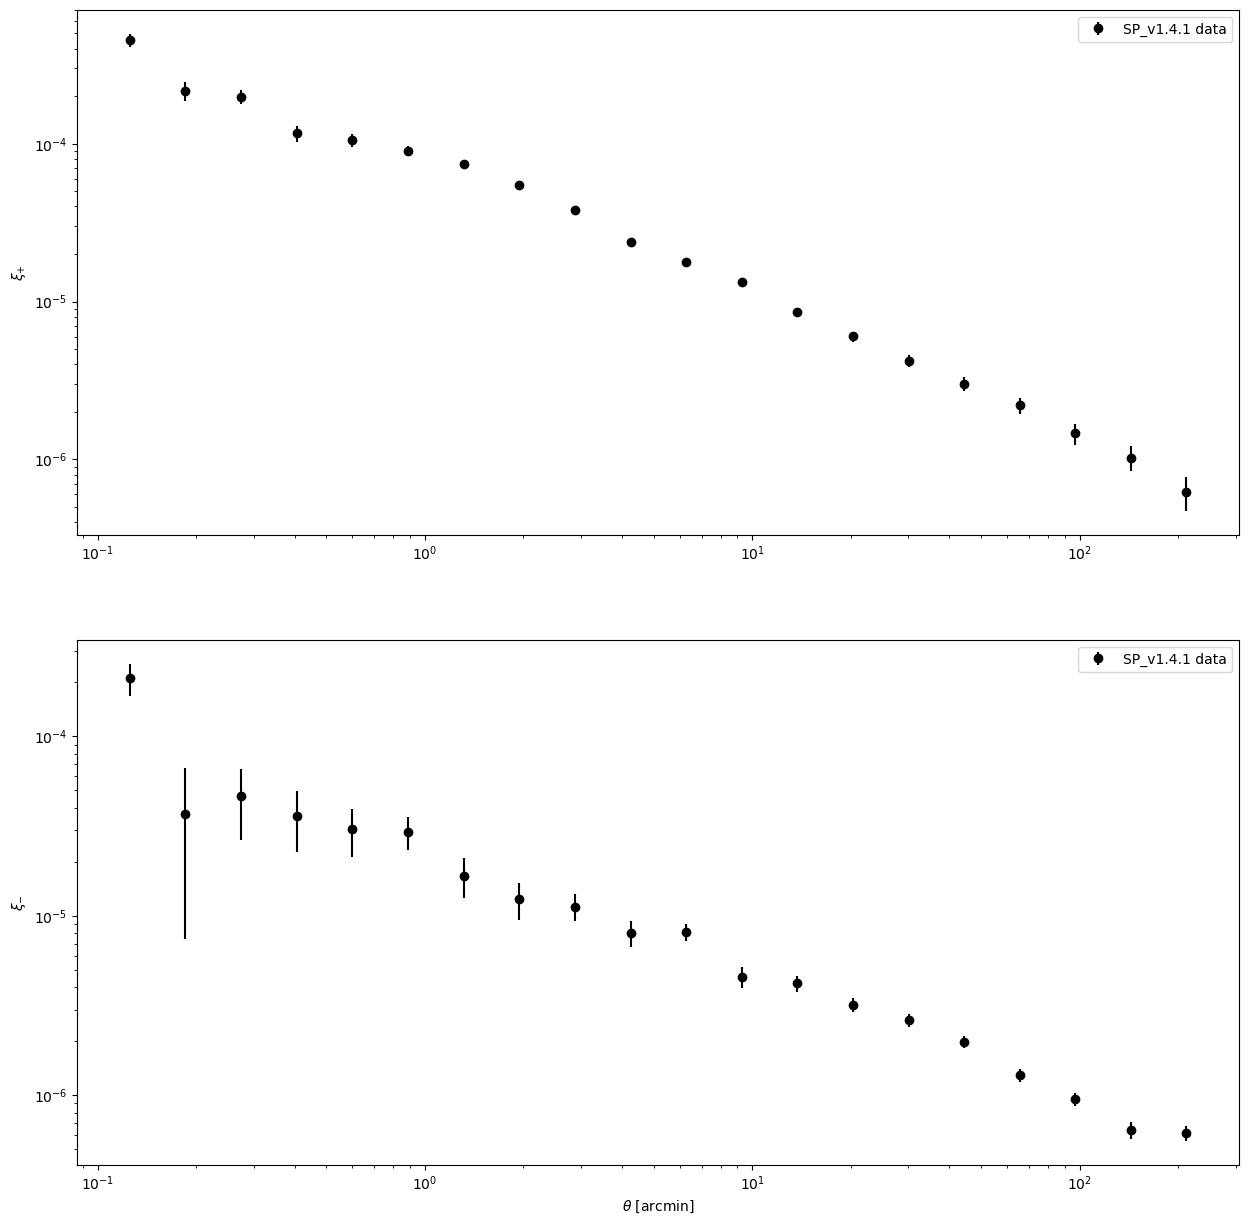

In [8]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.1 data', color='black')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:], fmt='o', label='SP_v1.4.1 data', color='black')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

In [9]:
#Get samples from the chain
samples = chains[0].samples
alpha, beta = samples[:100, 3], samples[:100, 4]
prior_alpha = np.random.normal(loc=0.019, scale=0.009, size=1000)
prior_beta = np.random.normal(loc=1.05, scale=0.091, size=1000)

In [10]:
#Get prediction for the level of systematics
rho_stats = fits.open(f'/home/guerrini/sp_validation/cosmo_inference/data/{version}/cosmosis_{version}.fits')['RHO_STATS'].data

def get_xi_sys(alpha, beta, rho_stats):
    eta = (alpha + 1.932) / (120.213)
    xi_sys_p = alpha**2 * rho_stats['rho_0_p'] + beta**2 * rho_stats['rho_1_p'] + eta**2 * rho_stats['rho_3_p'] + 2*alpha*beta*rho_stats['rho_2_p'] + 2*alpha*eta*rho_stats['rho_5_p'] + 2*beta*eta*rho_stats['rho_4_p']
    xi_sys_m = alpha**2 * rho_stats['rho_0_m'] + beta**2 * rho_stats['rho_1_m'] + eta**2 * rho_stats['rho_3_m'] + 2*alpha*beta*rho_stats['rho_2_m'] + 2*alpha*eta*rho_stats['rho_5_m'] + 2*beta*eta*rho_stats['rho_4_m']
    return xi_sys_p, xi_sys_m

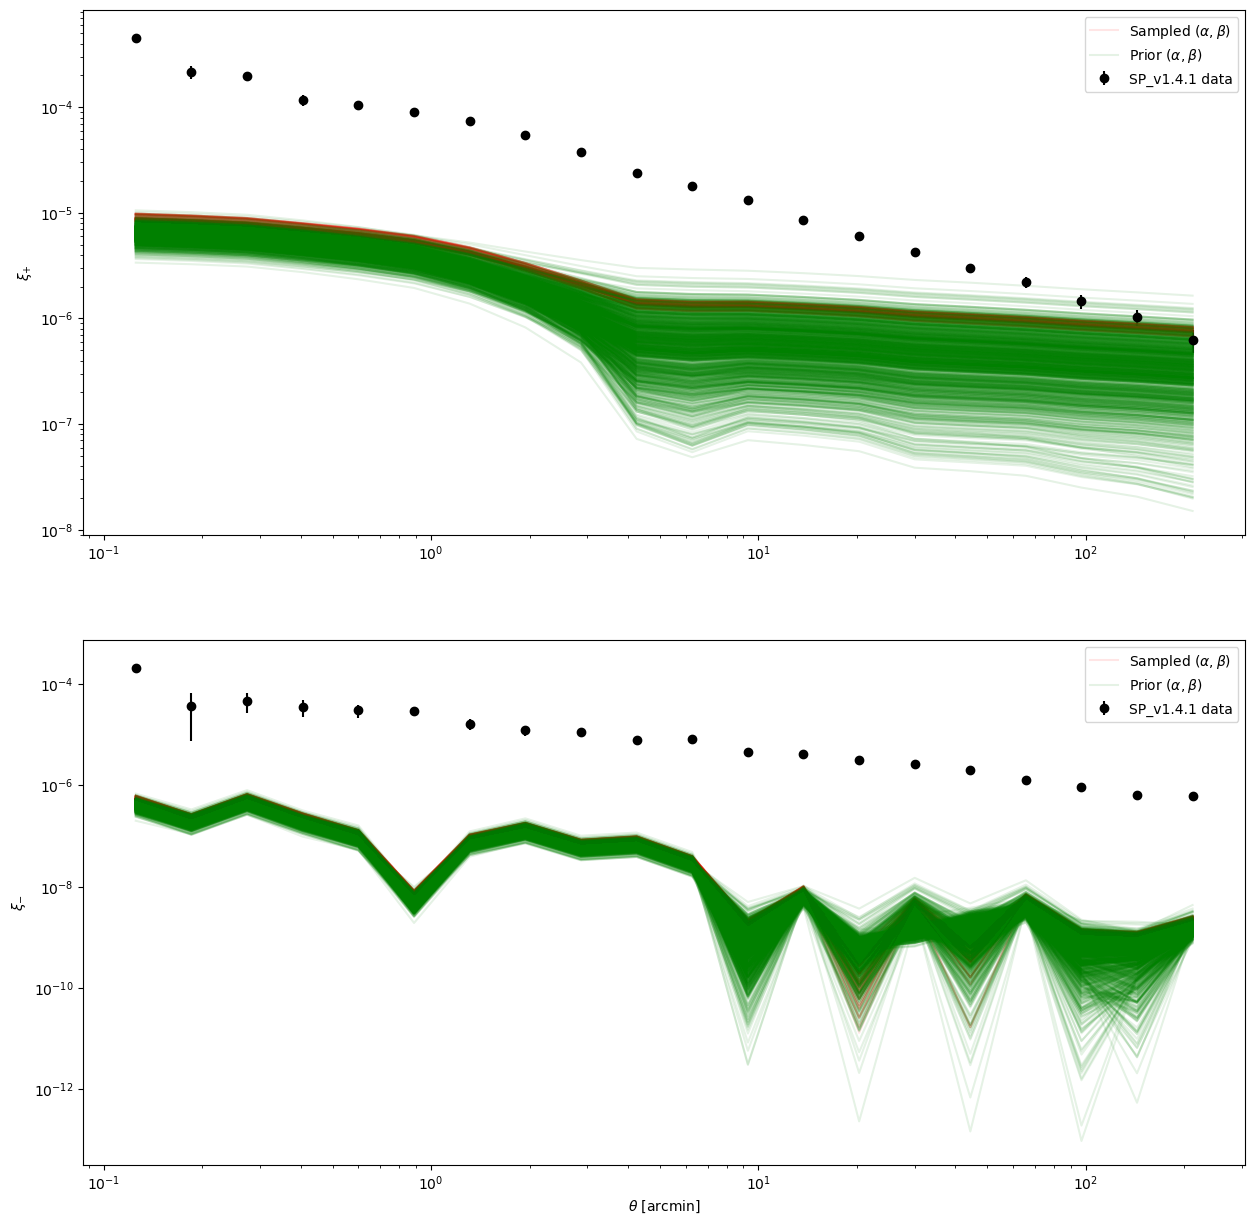

In [11]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.1 data', color='black')

i=0
for a, b in zip(alpha, beta):
    xi_sys_p, _ = get_xi_sys(a, b, rho_stats)
    if i == len(alpha)-1:
        plt.plot(xi_plus['ANG'], xi_sys_p, color='red', alpha=0.1, label=r'Sampled $(\alpha, \beta)$')
    else:
        plt.plot(xi_plus['ANG'], xi_sys_p, color='red', alpha=0.1)
    i+=1

i=0
for a, b in zip(prior_alpha, prior_beta):
    xi_sys_p, _ = get_xi_sys(a, b, rho_stats)
    if i == len(prior_alpha)-1:
        plt.plot(xi_plus['ANG'], xi_sys_p, color='green', alpha=0.1, label=r'Prior $(\alpha, \beta)$')
    else:
        plt.plot(xi_plus['ANG'], xi_sys_p, color='green', alpha=0.1)
    i+=1

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:], fmt='o', label='SP_v1.4.1 data', color='black')

i=0
for a, b in zip(alpha, beta):
    _, xi_sys_m = get_xi_sys(a, b, rho_stats)
    if i == len(alpha) - 1:
        plt.plot(xi_minus['ANG'], np.abs(xi_sys_m), color='red', alpha=0.1, label=r'Sampled $(\alpha, \beta)$')
    else:
        plt.plot(xi_minus['ANG'], np.abs(xi_sys_m), color='red', alpha=0.1)
    i+=1

i=0
for a, b in zip(prior_alpha, prior_beta):
    _, xi_sys_m = get_xi_sys(a, b, rho_stats)
    if i == len(prior_alpha) - 1:
        plt.plot(xi_minus['ANG'], np.abs(xi_sys_m), color='green', alpha=0.1, label=r'Prior $(\alpha, \beta)$')
    else:
        plt.plot(xi_minus['ANG'], np.abs(xi_sys_m), color='green', alpha=0.1)
    i+=1

plt.ylabel(r'$\xi_{-}$')
plt.xlabel(r'$\theta$ [arcmin]')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

In [12]:
#Get theory prediction for the correlation function
def compute_xi(omega_m, sigma_8, a, theta_arcmin):
    #Define the cosmology
    h0 = 0.6727
    ombh2 = 0.02236
    n_s = 0.9649
    omega_b = ombh2 / h0**2
    tau = 0.0544
    cosmo = ccl.Cosmology(
        Omega_c = omega_m - omega_b,
        Omega_b = omega_b,
        h = h0,
        n_s = n_s,
        sigma8 = sigma_8,
        Omega_k = 0.,
        w0 = -1.,
        wa = 0.,
        transfer_function='eisenstein_hu',
    )


    #Define the redshift distribution
    z, dndz = np.loadtxt('/home/guerrini/sp_validation/cosmo_inference/cosmocov_config/dndz_test.txt', unpack=True)

    tracer = ccl.WeakLensingTracer(cosmo, (z, dndz), ia_bias=None)

    #COmpute the angular power spectrum C_ell
    ell = np.logspace(0, np.log10(10000), 1000)
    cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

    #Compute the 2PCF
    theta_deg = theta_arcmin / 60
    #xi+ fit
    xi_p_theta = ccl.correlation(cosmo, ell, cl_gg, theta_deg, type='GG+')
    #xi- fit
    xi_m_theta = ccl.correlation(cosmo, ell, cl_gg, theta_deg, type='GG-')

    return xi_p_theta, xi_m_theta

In [13]:
theta_arcmin = xi_plus['ANG']
xi_p_theta, xi_m_theta = compute_xi(0.7, 0.6, 1.0, theta_arcmin)

/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/pyccl/tracers.py:110: CCLWarning: The number of samples in the n(z) (201) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
  warnings.warn(


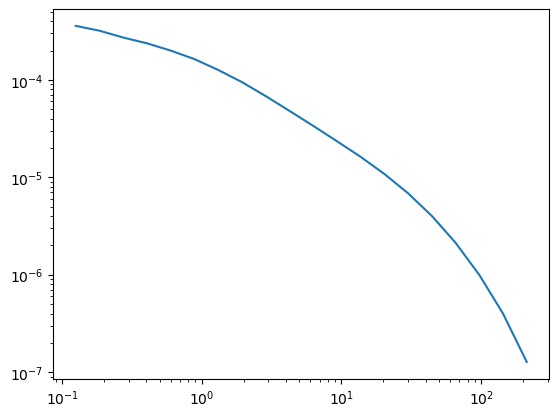

In [14]:
plt.figure()

plt.plot(theta_arcmin, xi_p_theta)

plt.xscale('log')
plt.yscale('log')

plt.show()

In [15]:
num_samples = 10
index_samples = np.random.permutation(np.arange(100))[:10]
Omega_m, sigma_8, alpha, beta = samples[index_samples, 0], samples[index_samples, 1], samples[index_samples, 3], samples[index_samples, 4]

In [19]:
reasonable_chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format('raw_SP_v1.4.1' +'/','SP_v1.4.1'),
                                    settings={'ignore_rows':0.3})
reasonable_samples = reasonable_chain.samples
reasonable_om_m, reasonable_sig_8 = reasonable_samples[index_samples, 0], reasonable_samples[index_samples, 1]

/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/pyccl/tracers.py:110: CCLWarning: The number of samples in the n(z) (201) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
  warnings.warn(


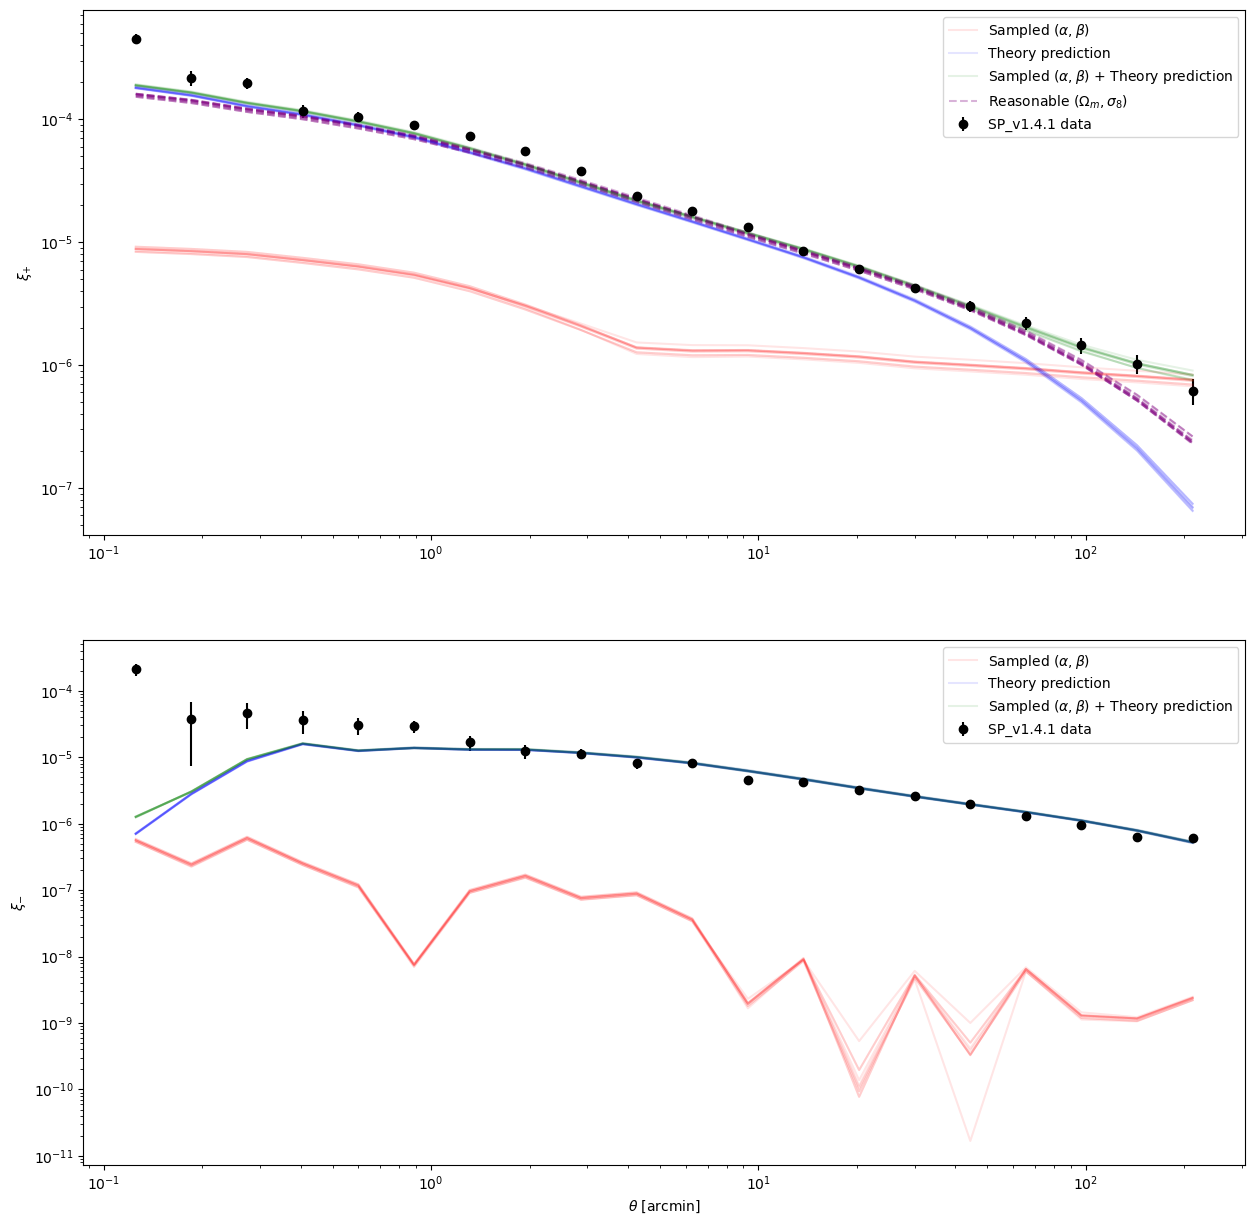

In [25]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(xi_plus['ANG'], xi_plus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.1 data', color='black')

i=0
for a, b, om_m, sig_8, reasonable_om, reasonable_sig in zip(alpha, beta, Omega_m, sigma_8, reasonable_om_m, reasonable_sig_8):
    xi_sys_p, _ = get_xi_sys(a, b, rho_stats)
    theta_arcmin = xi_plus['ANG']
    xi_p_theta, xi_m_theta = compute_xi(om_m, sig_8, 1.0, theta_arcmin)
    reasonable_xi_p_theta, _ = compute_xi(reasonable_om, reasonable_sig, 1.0, theta_arcmin)
    if i == len(alpha)-1:
        plt.plot(xi_plus['ANG'], xi_sys_p, color='red', alpha=0.1, label=r'Sampled $(\alpha, \beta)$')
        plt.plot(theta_arcmin, xi_p_theta, color='blue', alpha=0.1, label=r'Theory prediction')
        plt.plot(theta_arcmin, xi_p_theta + xi_sys_p, color='green', alpha=0.1, label=r'Sampled $(\alpha, \beta)$ + Theory prediction')
        plt.plot(theta_arcmin, reasonable_xi_p_theta, color='purple', linestyle='--', alpha=0.3, label=r'Reasonable $(\Omega_m, \sigma_8)$')
    else:
        plt.plot(xi_plus['ANG'], xi_sys_p, color='red', alpha=0.1)
        plt.plot(theta_arcmin, xi_p_theta, color='blue', alpha=0.1)
        plt.plot(theta_arcmin, xi_p_theta + xi_sys_p, color='green', alpha=0.1)
        plt.plot(theta_arcmin, reasonable_xi_p_theta, color='purple', linestyle='--', alpha=0.3)
    i+=1





plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(212)

plt.errorbar(xi_minus['ANG'], xi_minus['VALUE'], yerr=np.sqrt(np.diag(cov_mat))[20:], fmt='o', label='SP_v1.4.1 data', color='black')

i=0
for a, b, om_m, sig_8 in zip(alpha, beta, Omega_m, sigma_8):
    _, xi_sys_m = get_xi_sys(a, b, rho_stats)
    theta_arcmin = xi_minus['ANG']
    xi_p_theta, xi_m_theta = compute_xi(om_m, sig_8, 1.0, theta_arcmin)
    if i == len(alpha) - 1:
        plt.plot(xi_minus['ANG'], np.abs(xi_sys_m), color='red', alpha=0.1, label=r'Sampled $(\alpha, \beta)$')
        plt.plot(theta_arcmin, xi_m_theta, color='blue', alpha=0.1, label=r'Theory prediction')
        plt.plot(theta_arcmin, xi_m_theta + np.abs(xi_sys_m), color='green', alpha=0.1, label=r'Sampled $(\alpha, \beta)$ + Theory prediction')
    else:
        plt.plot(xi_minus['ANG'], np.abs(xi_sys_m), color='red', alpha=0.1)
        plt.plot(theta_arcmin, xi_m_theta, color='blue', alpha=0.1)
        plt.plot(theta_arcmin, xi_m_theta + np.abs(xi_sys_m), color='green', alpha=0.1)
    i+=1

plt.ylabel(r'$\xi_{-}$')
plt.xlabel(r'$\theta$ [arcmin]')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.savefig('leakage_investigation.png')
plt.show()